# Comparaison 6 modèles — Dataset 3 FEMTO PRONOSTIA — by_condition

| Champ | Valeur |
|-------|--------|
| **Scénario** | by_condition : Condition 1 (1800rpm, 4000N) → Condition 2 (1650rpm, 4200N) → Condition 3 (1500rpm, 5000N) |
| **Modèles** | TinyOL · EWC · HDC · KMeans · Mahalanobis · DBSCAN |
| **Dataset** | FEMTO PRONOSTIA (IEEE PHM 2012) — données accélérométrie réelles, 13 features statistiques |
| **Sprint** | 10 — S10-07 |

Ce notebook agrège les résultats des expériences **exp_050, exp_051, exp_052, exp_053, exp_054, exp_055**.
Il constitue le support principal pour la **section Gap 1** du manuscrit (validation sur données industrielles réelles).

**Figures générées** :
1. `radar_comparison.png` — radar 5-axes (AA, Stabilité, BWT, RAM, Vitesse)
2. `barplot_aa_comparison.png` — barplot AA/AF/BWT pour les 6 modèles
3. `acc_matrix_grid.png` — grille 2×3 des matrices d'accuracy
4. `scatter_ram_vs_accuracy.png` — trade-off RAM/performance (Gap 2, budget STM32 ≤ 64 Ko)
5. `scatter_flops_vs_accuracy.png` — coût de calcul portable (MACs, indépendant de la machine)
6. `scatter_latency_vs_accuracy.png` — latence PC (budget 100 ms, ⚠ non transférable au MCU)
7. `performance_by_condition_bar.png` — accuracy finale par condition de fonctionnement

In [1]:
# Section 1 — Setup + chargement normalisé des 6 modèles
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

# --- CWD navigation ---
_cwd = Path(".").resolve()
if _cwd.name == "pronostia_by_condition":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_metrics_comparison, plot_model_radar, plot_performance_by_task_bar, save_figure,
)
from src.evaluation.compute_cost import compute_macs

FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/comparison/pronostia/by_condition"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES = ["Condition 1 (1800rpm, 4000N)", "Condition 2 (1650rpm, 4200N)", "Condition 3 (1500rpm, 5000N)"]
MODEL_ORDER = ["TinyOL", "EWC", "HDC", "KMeans", "Mahalanobis", "DBSCAN"]
PRONOSTIA_N_FEATURES = 13  # input_shape: [1, 13] — 13 features statistiques (RMS, kurtosis, etc.)

# Mapping : (exp_dir, metrics_file, npy_file | None)
# npy_file=None → acc_matrix embarquée dans le JSON
MODEL_EXP_MAP = {
    "TinyOL":      ("exp_052_tinyol_pronostia_by_condition",      "metrics.json",     None),
    "EWC":         ("exp_050_ewc_pronostia_by_condition",         "metrics.json",     "acc_matrix_ewc.npy"),
    "HDC":         ("exp_051_hdc_pronostia_by_condition",         "metrics.json",     None),
    "KMeans":      ("exp_053_kmeans_pronostia_by_condition",      "metrics_all.json", "acc_matrix_kmeans_dataset3.npy"),
    "Mahalanobis": ("exp_054_mahalanobis_pronostia_by_condition", "metrics_all.json", "acc_matrix_mahalanobis_dataset3.npy"),
    "DBSCAN":      ("exp_055_dbscan_pronostia_by_condition",      "metrics_all.json", "acc_matrix_dbscan_dataset3.npy"),
}

BASE = REPO_ROOT / "experiments"


def normalize_metrics(raw: dict, model_name: str) -> dict:
    """Normalise les différents schémas metrics.json vers un dict commun.

    Clés retournées : aa, af, bwt, ram_peak_bytes, inference_latency_ms, n_params, auroc_avg.
    """
    if model_name == "TinyOL":
        return {
            "aa":  raw["acc_final"],
            "af":  raw["avg_forgetting"],
            "bwt": raw["backward_transfer"],
            "ram_peak_bytes": raw["ram_peak_bytes"],
            "inference_latency_ms": raw["inference_latency_ms"],
            "n_params": raw.get("n_params_encoder", 532) + raw.get("n_params_oto", 10),
            "auroc_avg": None,
        }
    if model_name == "EWC":
        cl  = raw["cl_metrics"]["ewc"]
        mem = raw["cl_metrics"]["memory"]["forward"]
        return {
            "aa": cl["aa"], "af": cl["af"], "bwt": cl["bwt"],
            "ram_peak_bytes": mem["ram_peak_bytes"],
            "inference_latency_ms": mem["inference_latency_ms"],
            "n_params": mem["n_params"],
            "auroc_avg": None,
        }
    if model_name == "HDC":
        cl = raw["cl_metrics"]
        return {
            "aa": cl["aa"], "af": cl["af"], "bwt": cl["bwt"],
            "ram_peak_bytes": cl["ram_peak_bytes"],
            "inference_latency_ms": cl["inference_latency_ms"],
            "n_params": cl.get("n_params", 2048),
            "auroc_avg": None,
        }
    # KMeans / Mahalanobis / DBSCAN — root key = lowercase model name
    inner = raw[model_name.lower()]
    return {
        "aa": inner["aa"], "af": inner["af"], "bwt": inner["bwt"],
        "ram_peak_bytes": inner["ram_peak_bytes"],
        "inference_latency_ms": inner["inference_latency_ms"],
        "n_params": inner.get("n_params", 0),
        "auroc_avg": inner.get("auroc_avg"),
    }


def load_acc_matrix(model_name: str, raw: dict, npy_file: str | None, exp_dir: Path) -> np.ndarray:
    """Charge la matrice d'accuracy 3×3 (NaN pour upper-triangle / cellules non vues)."""
    if npy_file is not None:
        return np.array(np.load(exp_dir / npy_file, allow_pickle=True), dtype=float)
    # Matrices embarquées dans le JSON
    if model_name == "EWC":
        raw_mat = raw["cl_metrics"]["ewc"]["acc_matrix"]
    elif model_name == "HDC":
        raw_mat = raw["cl_metrics"]["acc_matrix"]
    else:  # TinyOL : liste triangulaire de longueur croissante
        raw_mat = raw["acc_matrix"]
    n = 3
    mat = np.full((n, n), np.nan, dtype=float)
    for i, row in enumerate(raw_mat):
        for j, v in enumerate(row):
            if v is not None:
                mat[i, j] = v
    return mat


# Chargement des 6 modèles
results = {}
acc_matrices = {}

for model in MODEL_ORDER:
    exp_dir_name, metrics_file, npy_file = MODEL_EXP_MAP[model]
    exp_dir = BASE / exp_dir_name / "results"
    metrics_path = exp_dir / metrics_file
    if not metrics_path.exists():
        print(f"⚠️  {exp_dir_name} non disponible — mock activé")
        results[model] = {"aa": 0.0, "af": 0.0, "bwt": 0.0, "ram_peak_bytes": 0,
                          "inference_latency_ms": 0.0, "n_params": 0, "auroc_avg": None}
        acc_matrices[model] = np.zeros((3, 3))
        continue
    raw = json.loads(metrics_path.read_text())
    results[model] = normalize_metrics(raw, model)
    acc_matrices[model] = load_acc_matrix(model, raw, npy_file, exp_dir)
    r = results[model]
    auroc_s = f"{r['auroc_avg']:.4f}" if r["auroc_avg"] is not None else "—"
    print(f"{model:12s} → AA={r['aa']:.4f} AF={r['af']:.4f} BWT={r['bwt']:+.4f} "
          f"RAM={r['ram_peak_bytes']/1024:5.1f}Ko lat={r['inference_latency_ms']:.5f}ms "
          f"n_params={r['n_params']} AUROC={auroc_s}")

print(f"\n6 modèles chargés | Date exécution : {datetime.now():%Y-%m-%d %H:%M}")

TinyOL       → AA=0.9297 AF=0.0198 BWT=-0.0198 RAM=  3.6Ko lat=0.00906ms n_params=542 AUROC=—
EWC          → AA=0.9819 AF=0.0000 BWT=+0.0049 RAM=  1.1Ko lat=0.03545ms n_params=993 AUROC=—
HDC          → AA=0.8051 AF=0.0454 BWT=-0.0454 RAM= 14.2Ko lat=0.11923ms n_params=2048 AUROC=—
KMeans       → AA=0.8900 AF=0.0308 BWT=-0.0308 RAM=  5.4Ko lat=0.31917ms n_params=26 AUROC=0.8549
Mahalanobis  → AA=0.7931 AF=0.1693 BWT=-0.1693 RAM=  1.7Ko lat=0.00816ms n_params=182 AUROC=0.7824
DBSCAN       → AA=0.9014 AF=0.0000 BWT=+0.0051 RAM=118.2Ko lat=0.27146ms n_params=11479 AUROC=0.8250

6 modèles chargés | Date exécution : 2026-04-27 16:47


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pronostia/by_condition/radar_comparison.png


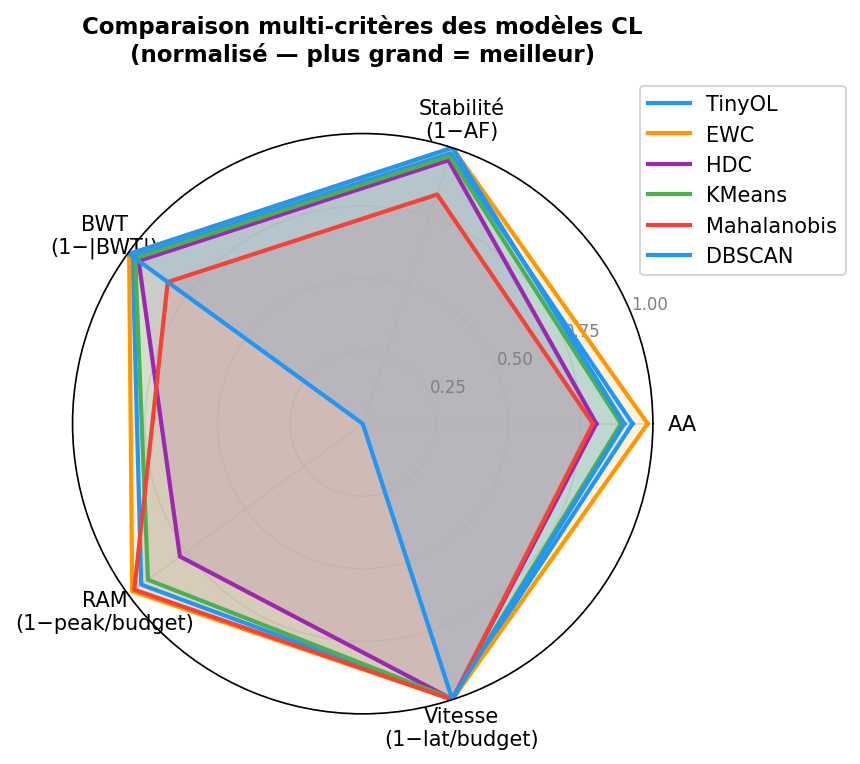

In [2]:
# Section 2 — Radar multi-critères (6 modèles, 5 axes normalisés)
# Axes : AA, Stabilité (1−AF), BWT neutre (1−|BWT|), RAM (1−peak/64Ko), Vitesse (1−lat/100ms)

fig = plot_model_radar(results, ram_budget_bytes=65536.0, latency_budget_ms=100.0)
save_figure(fig, FIGURES_DIR / "radar_comparison.png")
display(Image(str(FIGURES_DIR / "radar_comparison.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pronostia/by_condition/barplot_aa_comparison.png


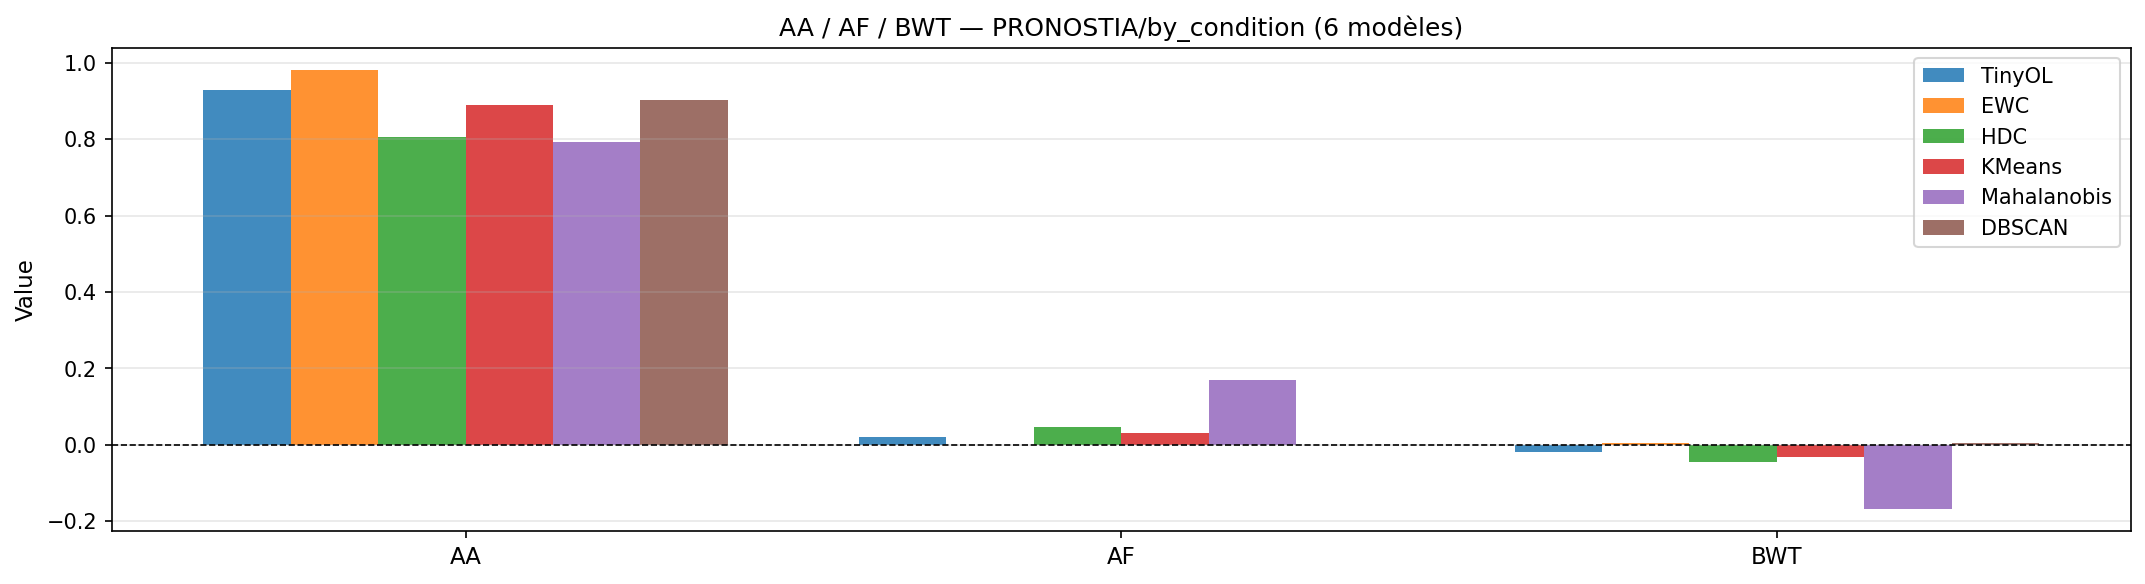

In [3]:
# Section 3 — Barplot AA/AF/BWT groupé (6 modèles)

fig = plot_metrics_comparison(
    results,
    metrics=["aa", "af", "bwt"],
    title="AA / AF / BWT — PRONOSTIA/by_condition (6 modèles)",
)
save_figure(fig, FIGURES_DIR / "barplot_aa_comparison.png")
display(Image(str(FIGURES_DIR / "barplot_aa_comparison.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pronostia/by_condition/acc_matrix_grid.png


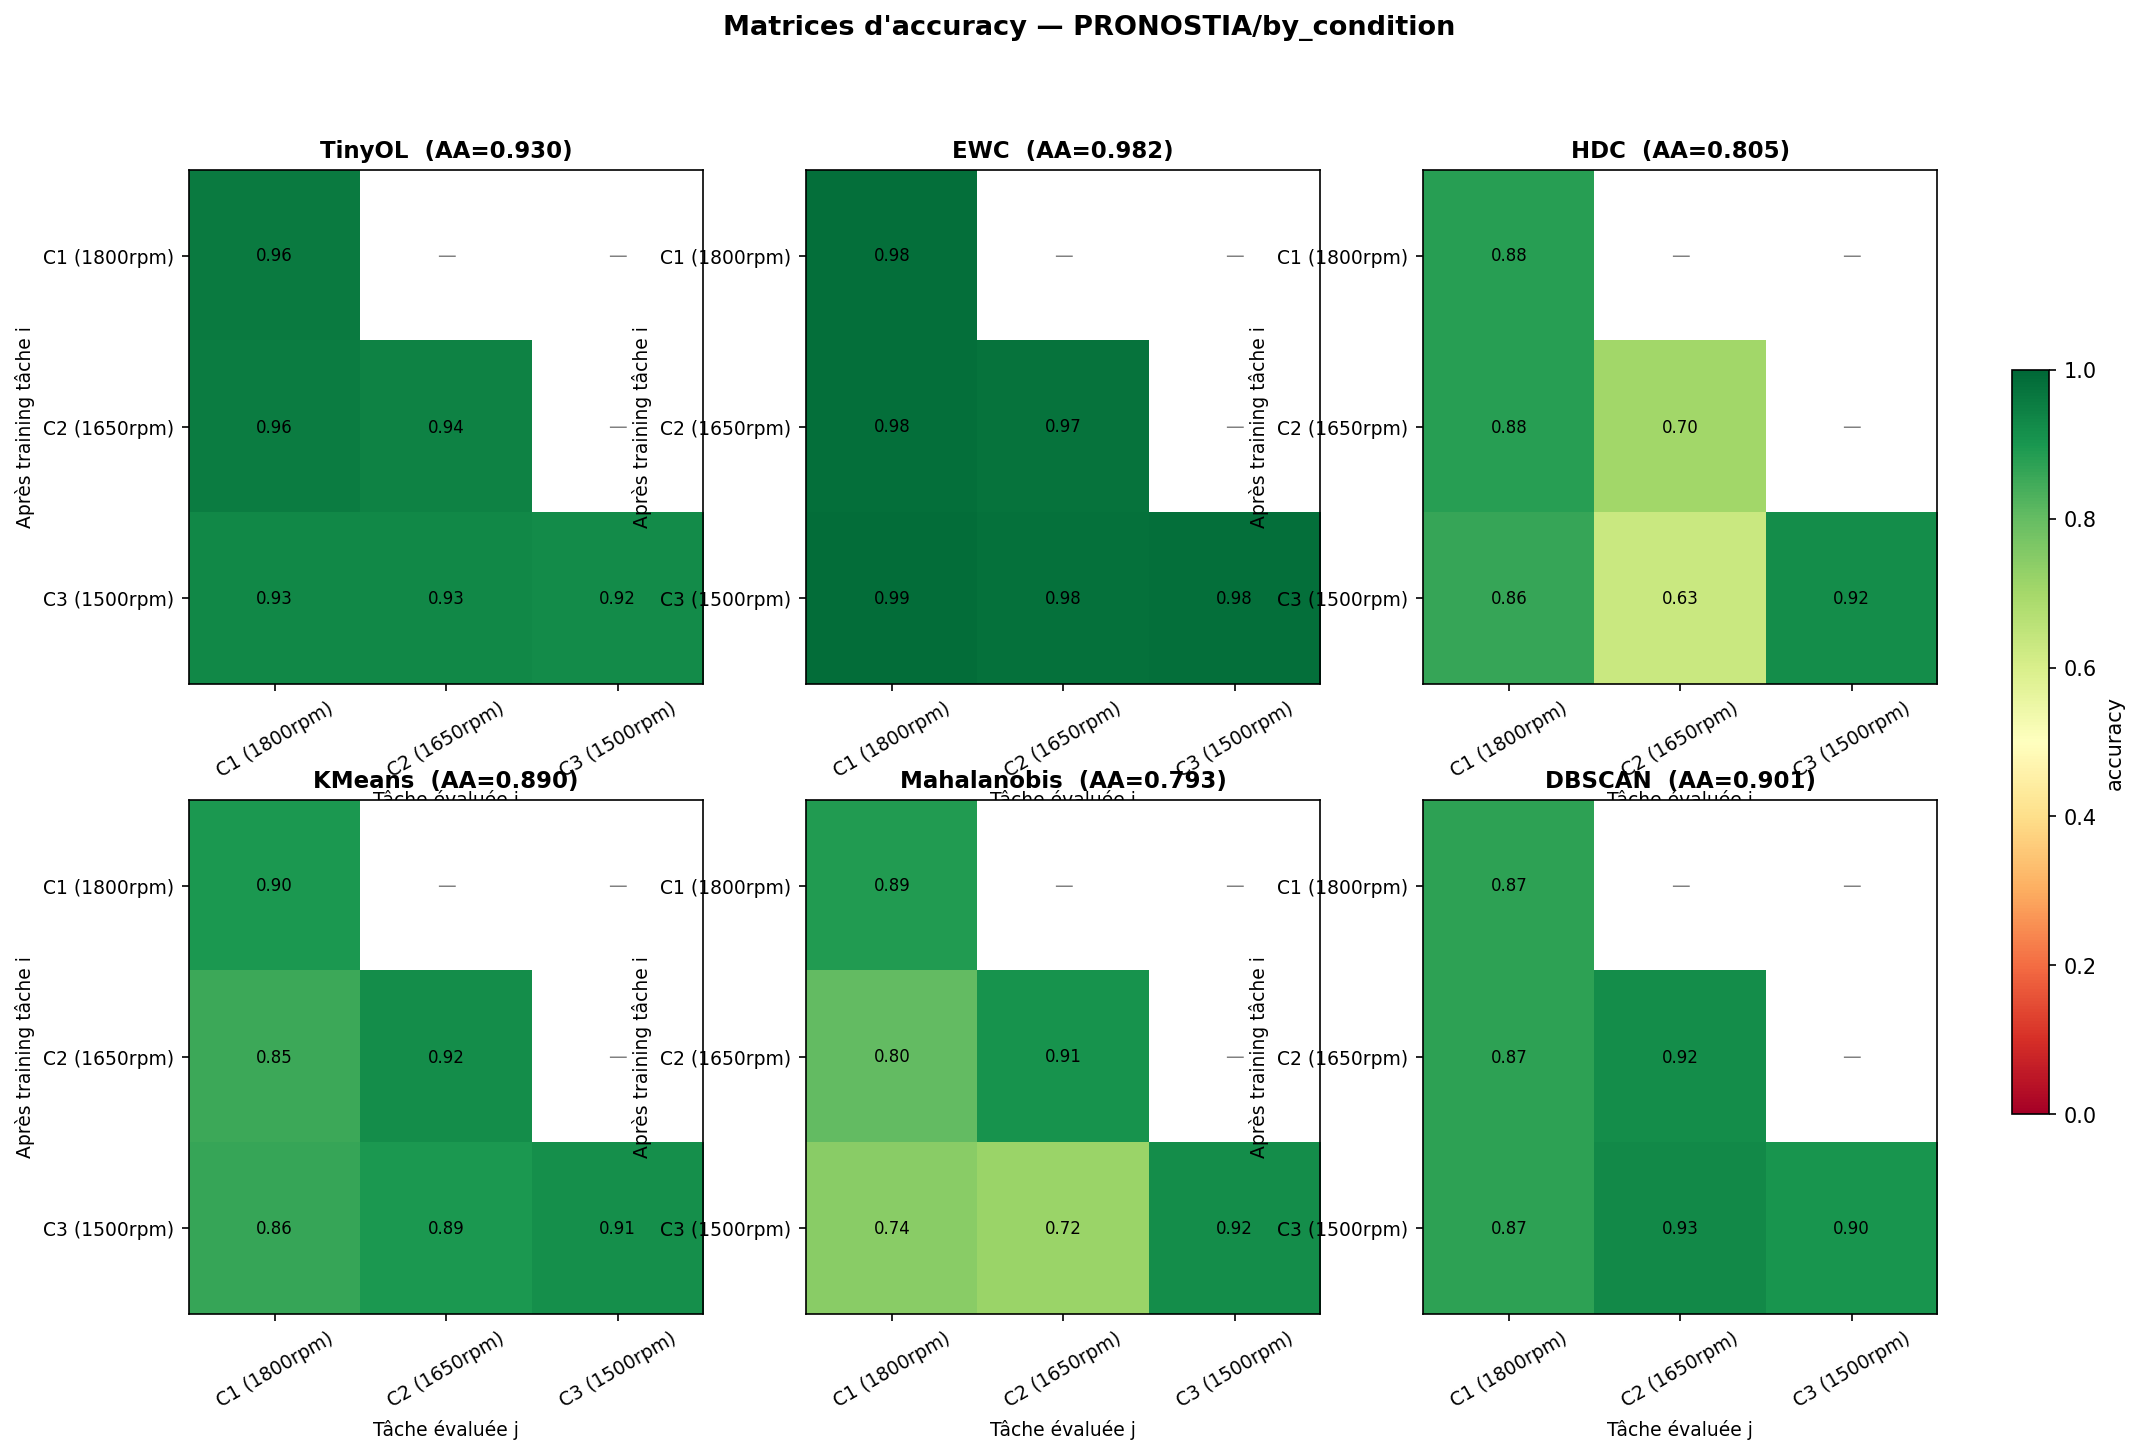

In [4]:
# Section 4 — Grille 2×3 des matrices d'accuracy des 6 modèles

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cmap = plt.get_cmap("RdYlGn")

# Noms de conditions raccourcis pour l'affichage
SHORT_TASK_NAMES = ["C1 (1800rpm)", "C2 (1650rpm)", "C3 (1500rpm)"]

for ax, model in zip(axes.flat, MODEL_ORDER):
    acc_mat = acc_matrices[model]
    masked = np.ma.masked_invalid(acc_mat)
    im = ax.imshow(masked, vmin=0, vmax=1, cmap=cmap)
    ax.set_title(f"{model}  (AA={results[model]['aa']:.3f})", fontsize=11, fontweight="bold")
    ax.set_xticks(range(len(SHORT_TASK_NAMES)))
    ax.set_yticks(range(len(SHORT_TASK_NAMES)))
    ax.set_xticklabels(SHORT_TASK_NAMES, rotation=30, fontsize=9)
    ax.set_yticklabels(SHORT_TASK_NAMES, fontsize=9)
    ax.set_xlabel("Tâche évaluée j", fontsize=9)
    ax.set_ylabel("Après training tâche i", fontsize=9)
    for i in range(acc_mat.shape[0]):
        for j in range(acc_mat.shape[1]):
            v = acc_mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                        color="black" if v > 0.5 else "white")
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="grey")

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04, label="accuracy")
fig.suptitle("Matrices d'accuracy — PRONOSTIA/by_condition", fontsize=13, fontweight="bold")
save_figure(fig, FIGURES_DIR / "acc_matrix_grid.png")
display(Image(str(FIGURES_DIR / "acc_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pronostia/by_condition/scatter_ram_vs_accuracy.png


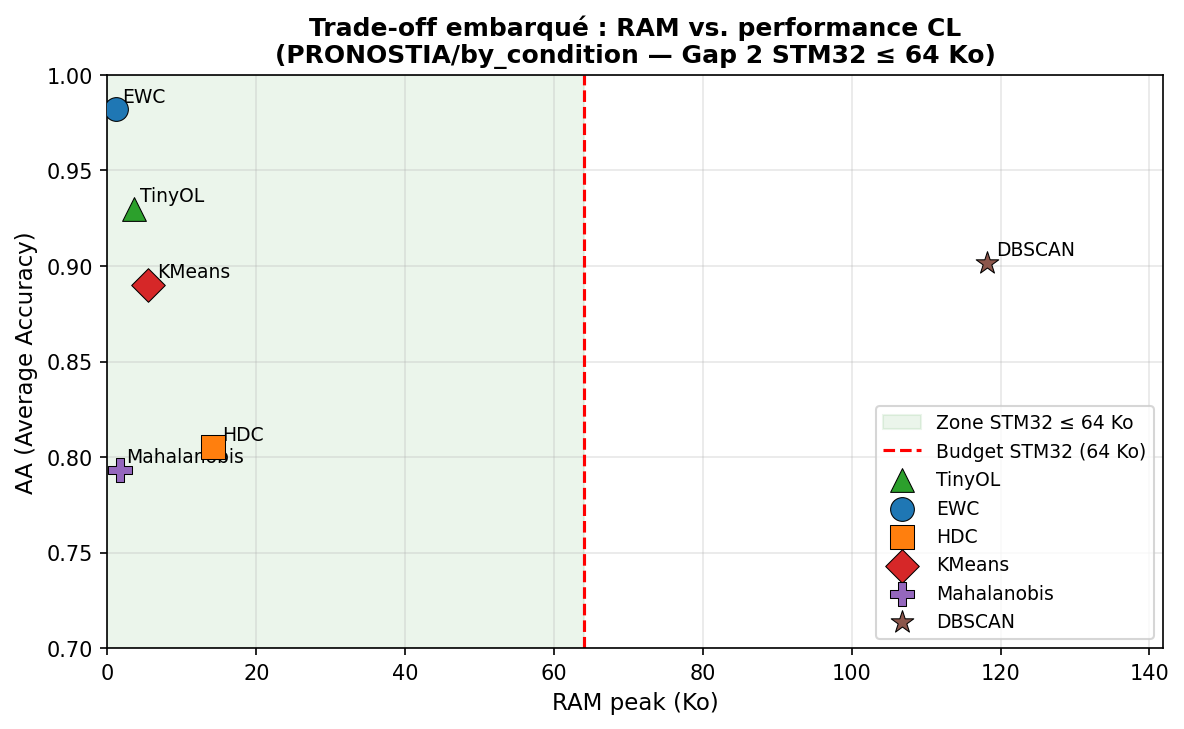

In [5]:
# Section 5a — Scatter RAM peak vs. accuracy (Gap 2 — STM32 ≤ 64 Ko)
# Format cohérent avec notebooks/cl_eval/baselines/pronostia_single_task.ipynb (cell-6)

STM32_RAM_LIMIT_KB = 64.0

SCATTER_MARKERS: dict[str, tuple[str, str]] = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

fig, ax = plt.subplots(figsize=(8, 5))

ax.axvspan(0, STM32_RAM_LIMIT_KB, alpha=0.08, color="green",
           label=f"Zone STM32 ≤ {STM32_RAM_LIMIT_KB:.0f} Ko")
ax.axvline(STM32_RAM_LIMIT_KB, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget STM32 ({STM32_RAM_LIMIT_KB:.0f} Ko)")

for name in MODEL_ORDER:
    r = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    acc    = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    x_offset = 0.8 if ram_kb < 5 else 1.2
    ax.annotate(name, xy=(ram_kb, acc), xytext=(ram_kb + x_offset, acc + 0.004), fontsize=9)

max_ram_kb = max(r["ram_peak_bytes"] for r in results.values()) / 1024
ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. performance CL\n(PRONOSTIA/by_condition — Gap 2 STM32 ≤ 64 Ko)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, max_ram_kb * 1.2)
ax.set_ylim(0.70, 1.0)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_ram_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_ram_vs_accuracy.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pronostia/by_condition/scatter_flops_vs_accuracy.png


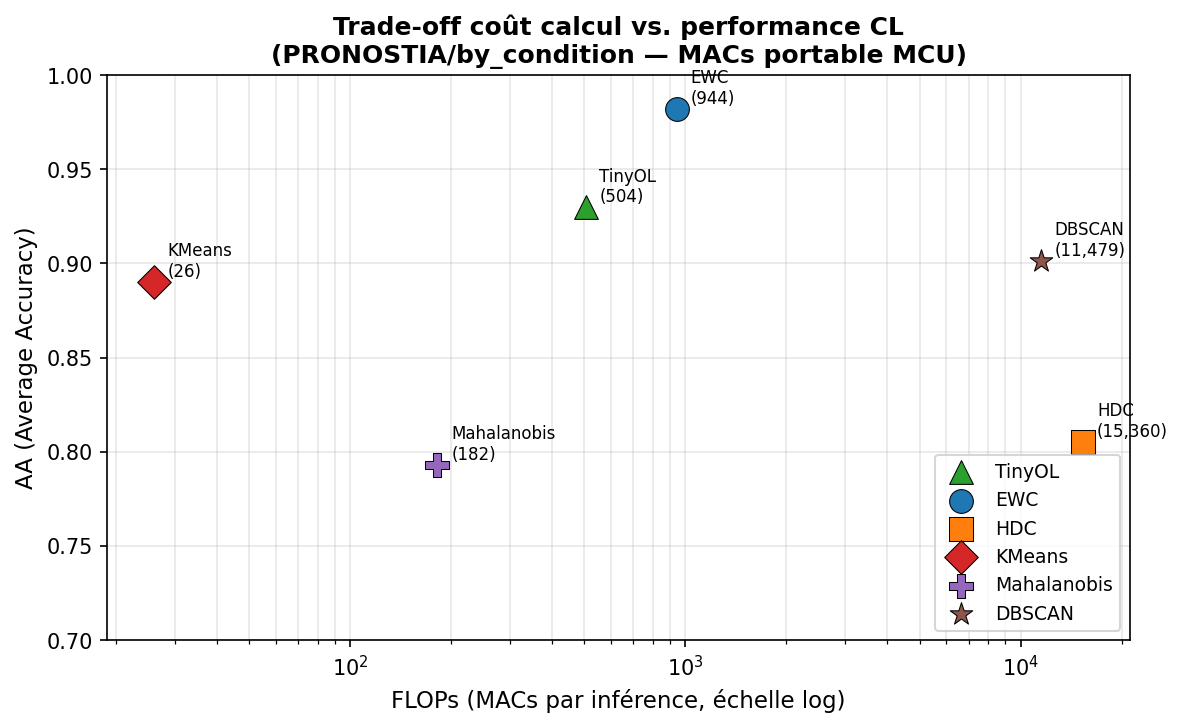

In [6]:
# Section 5b — Scatter FLOPs (MACs) vs. accuracy
# Coût de calcul portable — indépendant de la machine.
# n_features=13 (Pronostia), encoder_dims=[16,12,8] pour TinyOL

kmeans_k = max(1, results["KMeans"]["n_params"] // PRONOSTIA_N_FEATURES)
dbscan_n_core = max(1, results["DBSCAN"]["n_params"] // PRONOSTIA_N_FEATURES)

macs = {
    "EWC":         compute_macs("EWC",         n_features=PRONOSTIA_N_FEATURES, hidden_dims=[32, 16], n_classes=1),
    "TinyOL":      compute_macs("TinyOL",      n_features=PRONOSTIA_N_FEATURES, encoder_dims=[16, 12, 8], n_classes=1),
    "HDC":         compute_macs("HDC",         n_features=PRONOSTIA_N_FEATURES, dim_hv=1024, n_classes=2),
    "KMeans":      compute_macs("KMeans",      n_features=PRONOSTIA_N_FEATURES, n_clusters=kmeans_k),
    "Mahalanobis": compute_macs("Mahalanobis", n_features=PRONOSTIA_N_FEATURES),
    "DBSCAN":      compute_macs("DBSCAN",      n_features=PRONOSTIA_N_FEATURES, n_core_samples=dbscan_n_core),
}

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    m = macs[name]
    acc = results[name]["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(m, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(f"{name}\n({m:,})", xy=(m, acc), xytext=(m * 1.1, acc + 0.003), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("FLOPs (MACs par inférence, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off coût calcul vs. performance CL\n(PRONOSTIA/by_condition — MACs portable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.70, 1.0)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_flops_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_flops_vs_accuracy.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pronostia/by_condition/scatter_latency_vs_accuracy.png


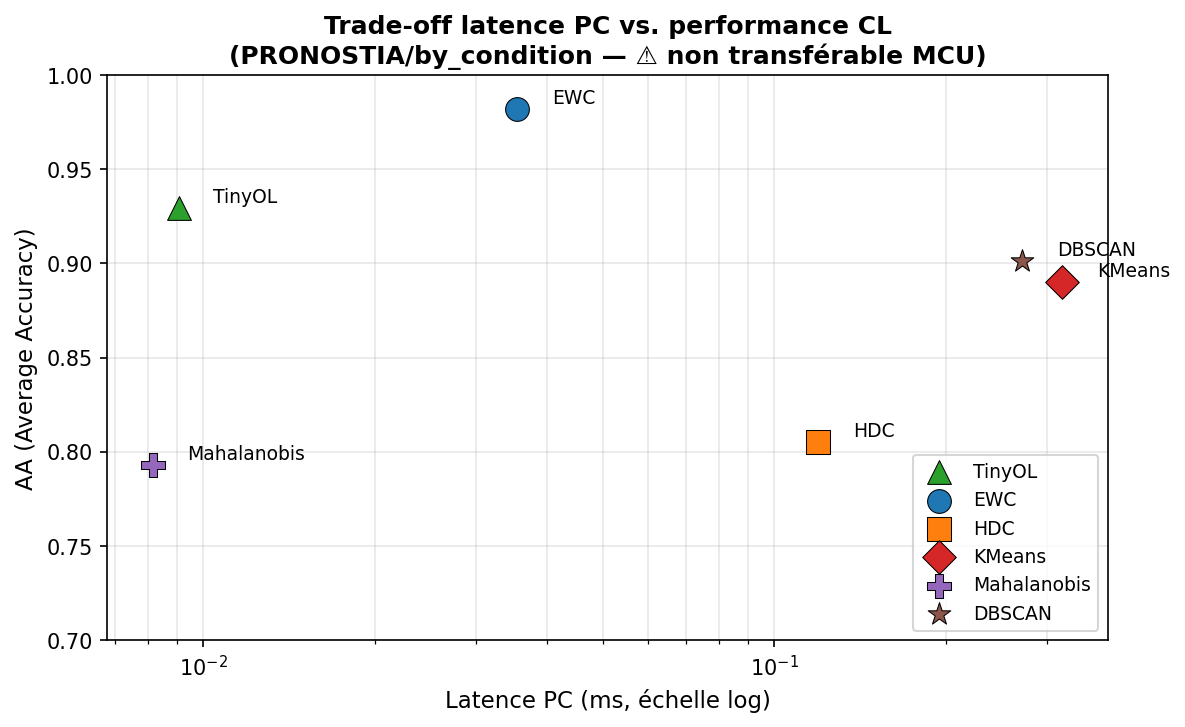

In [7]:
# Section 5c — Scatter latence PC vs. accuracy
# ⚠ Latence mesurée PC — non transférable directement au MCU.
# Le budget 100 ms est le plafond STM32N6 (cf. CLAUDE.md).

LATENCY_BUDGET_MS = 100.0

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    r = results[name]
    lat = r["inference_latency_ms"]
    acc = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(lat, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, xy=(lat, acc), xytext=(lat * 1.15, acc + 0.003), fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Latence PC (ms, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off latence PC vs. performance CL\n(PRONOSTIA/by_condition — ⚠ non transférable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.70, 1.0)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_latency_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_latency_vs_accuracy.png")))

In [8]:
# Section 6 — Tableau comparatif complet (6 modèles)

RAM_LIMIT = 64 * 1024

header = "| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |"
sep    = "|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|"

print(header)
print(sep)
rows_md = [header, sep]

for model in MODEL_ORDER:
    r = results[model]
    ram_b  = r["ram_peak_bytes"]
    ram_s  = f"{ram_b/1024:.1f} Ko{'  ⚠️' if ram_b > RAM_LIMIT else ''}"
    auroc  = r["auroc_avg"]
    auroc_s = f"{auroc:.4f}" if isinstance(auroc, (int, float)) else "—"
    n_par  = r["n_params"] if r["n_params"] else "—"
    macs_m = macs.get(model, 0)
    line = (
        f"| {model} | {r['aa']:.4f} | {r['af']:.4f} | {r['bwt']:+.4f} | "
        f"{auroc_s} | {ram_s} | {r['inference_latency_ms']:.5f} ms | {n_par} | {macs_m:,} |"
    )
    print(line)
    rows_md.append(line)

display(Markdown("### Tableau récapitulatif — 6 modèles CL (PRONOSTIA/by_condition)\n\n" +
                 "\n".join(rows_md)))

| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |
|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|
| TinyOL | 0.9297 | 0.0198 | -0.0198 | — | 3.6 Ko | 0.00906 ms | 542 | 504 |
| EWC | 0.9819 | 0.0000 | +0.0049 | — | 1.1 Ko | 0.03545 ms | 993 | 944 |
| HDC | 0.8051 | 0.0454 | -0.0454 | — | 14.2 Ko | 0.11923 ms | 2048 | 15,360 |
| KMeans | 0.8900 | 0.0308 | -0.0308 | 0.8549 | 5.4 Ko | 0.31917 ms | 26 | 26 |
| Mahalanobis | 0.7931 | 0.1693 | -0.1693 | 0.7824 | 1.7 Ko | 0.00816 ms | 182 | 182 |
| DBSCAN | 0.9014 | 0.0000 | +0.0051 | 0.8250 | 118.2 Ko  ⚠️ | 0.27146 ms | 11479 | 11,479 |


### Tableau récapitulatif — 6 modèles CL (PRONOSTIA/by_condition)

| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |
|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|
| TinyOL | 0.9297 | 0.0198 | -0.0198 | — | 3.6 Ko | 0.00906 ms | 542 | 504 |
| EWC | 0.9819 | 0.0000 | +0.0049 | — | 1.1 Ko | 0.03545 ms | 993 | 944 |
| HDC | 0.8051 | 0.0454 | -0.0454 | — | 14.2 Ko | 0.11923 ms | 2048 | 15,360 |
| KMeans | 0.8900 | 0.0308 | -0.0308 | 0.8549 | 5.4 Ko | 0.31917 ms | 26 | 26 |
| Mahalanobis | 0.7931 | 0.1693 | -0.1693 | 0.7824 | 1.7 Ko | 0.00816 ms | 182 | 182 |
| DBSCAN | 0.9014 | 0.0000 | +0.0051 | 0.8250 | 118.2 Ko  ⚠️ | 0.27146 ms | 11479 | 11,479 |

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pronostia/by_condition/performance_by_condition_bar.png


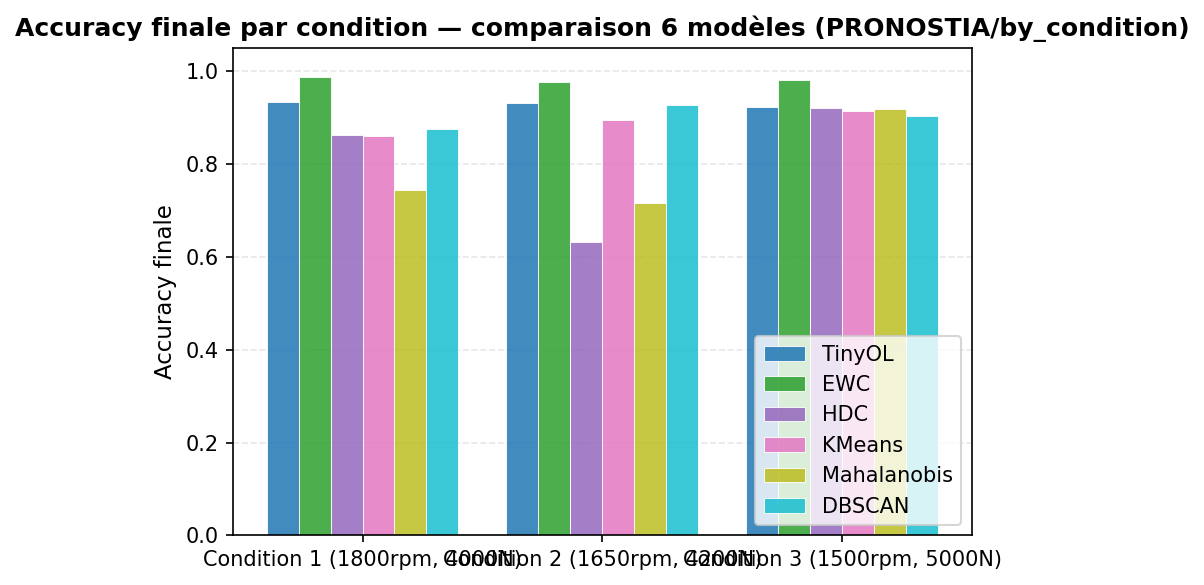

In [9]:
# Section 7 — Performance par condition de fonctionnement
# Accuracy finale (dernière ligne de la matrice) par condition

results_task = {
    model: {name: float(mat[-1, i]) for i, name in enumerate(TASK_NAMES)}
    for model, mat in acc_matrices.items()
}

fig = plot_performance_by_task_bar(
    results_task,
    task_names=TASK_NAMES,
    title="Accuracy finale par condition — comparaison 6 modèles (PRONOSTIA/by_condition)",
)
save_figure(fig, FIGURES_DIR / "performance_by_condition_bar.png")
display(Image(str(FIGURES_DIR / "performance_by_condition_bar.png")))

## Section 8 — Analyse de la complexité calculatoire (MACs)

| Métrique | Définition |
|----------|------------|
| **MACs inférence** | MACs/sample (modèle final après dernière tâche) |
| **MACs entraînement** | Coût total sur les N tâches CL |
| **Pareto** | Coût total (train + inférence×n_test) vs AA |

> Formules analytiques dans `src/evaluation/compute_cost.py`. Valeurs issues des configs YAML.

In [10]:
# Section 8a — Calcul des MACs (inférence + entraînement)
from src.evaluation.compute_cost import compute_macs, compute_training_macs

# Paramètres depuis les configs (ewc_config.yaml, hdc_config.yaml, unsupervised_config.yaml)
EWC_EPOCHS,   EWC_BATCH   = 10, 32
EWC_HIDDEN                = [32, 16]
TINYOL_ENC,   TINYOL_EPOCHS = [16, 12, 8], 1
HDC_DIM                   = 1024
KM_K_MIN, KM_K_MAX, KM_N_INIT, KM_MAX_ITER = 2, 10, 10, 300

# n_train par tâche CL  (2 roulements/condition × n_windows × 0.8 — valeurs approx., à affiner)
N_TRAIN_PER_TASK = [2112, 1920, 1536]
N_TEST_TOTAL     = 1392  # ≈ 20 % test

_NF = PRONOSTIA_N_FEATURES

# infer_macs déjà calculé en Section 5b (cell 6) → alias direct
infer_macs = macs  # dict model_name → MACs/sample

kmeans_k = max(1, results["KMeans"]["n_params"] // _NF)  # cohérent avec cell 6

def _train_task(name: str, n: int) -> int:
    if name == "EWC":
        return compute_training_macs("EWC", n_features=_NF, hidden_dims=EWC_HIDDEN,
                                     n_classes=1, n_samples=n,
                                     n_epochs=EWC_EPOCHS, batch_size=EWC_BATCH)
    elif name == "TinyOL":
        return compute_training_macs("TinyOL", n_features=_NF, encoder_dims=TINYOL_ENC,
                                     n_classes=1, n_samples=n, n_epochs=TINYOL_EPOCHS)
    elif name == "HDC":
        return compute_training_macs("HDC", n_features=_NF, dim_hv=HDC_DIM, n_samples=n)
    elif name == "KMeans":
        return compute_training_macs("KMeans", n_features=_NF, n_clusters=kmeans_k,
                                     n_samples=n, k_min=KM_K_MIN, k_max=KM_K_MAX,
                                     n_init=KM_N_INIT, max_iter=KM_MAX_ITER)
    elif name == "Mahalanobis":
        return compute_training_macs("Mahalanobis", n_features=_NF, n_samples=n)
    else:  # DBSCAN
        return compute_training_macs("DBSCAN", n_features=_NF, n_samples=n)

train_macs_per_task = {m: [_train_task(m, n) for n in N_TRAIN_PER_TASK] for m in MODEL_ORDER}
train_macs_total    = {m: sum(train_macs_per_task[m]) for m in MODEL_ORDER}

assert infer_macs["Mahalanobis"] == 182, f"Mahalanobis: {infer_macs['Mahalanobis']}"

print(f"{'Modèle':<14} {'Inférence (MACs/s)':>20} {'Train total (MACs)':>22}")
print("-" * 58)
for m in MODEL_ORDER:
    print(f"{m:<14} {infer_macs[m]:>20,} {train_macs_total[m]:>22,}")

Modèle           Inférence (MACs/s)     Train total (MACs)
----------------------------------------------------------
TinyOL                          504              8,418,816
EWC                             944            157,685,760
HDC                          15,360             79,822,848
KMeans                           26         13,389,742,080
Mahalanobis                     182              1,019,967
DBSCAN                       11,479            136,581,120


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/pronostia/by_condition/complexity_analysis.png


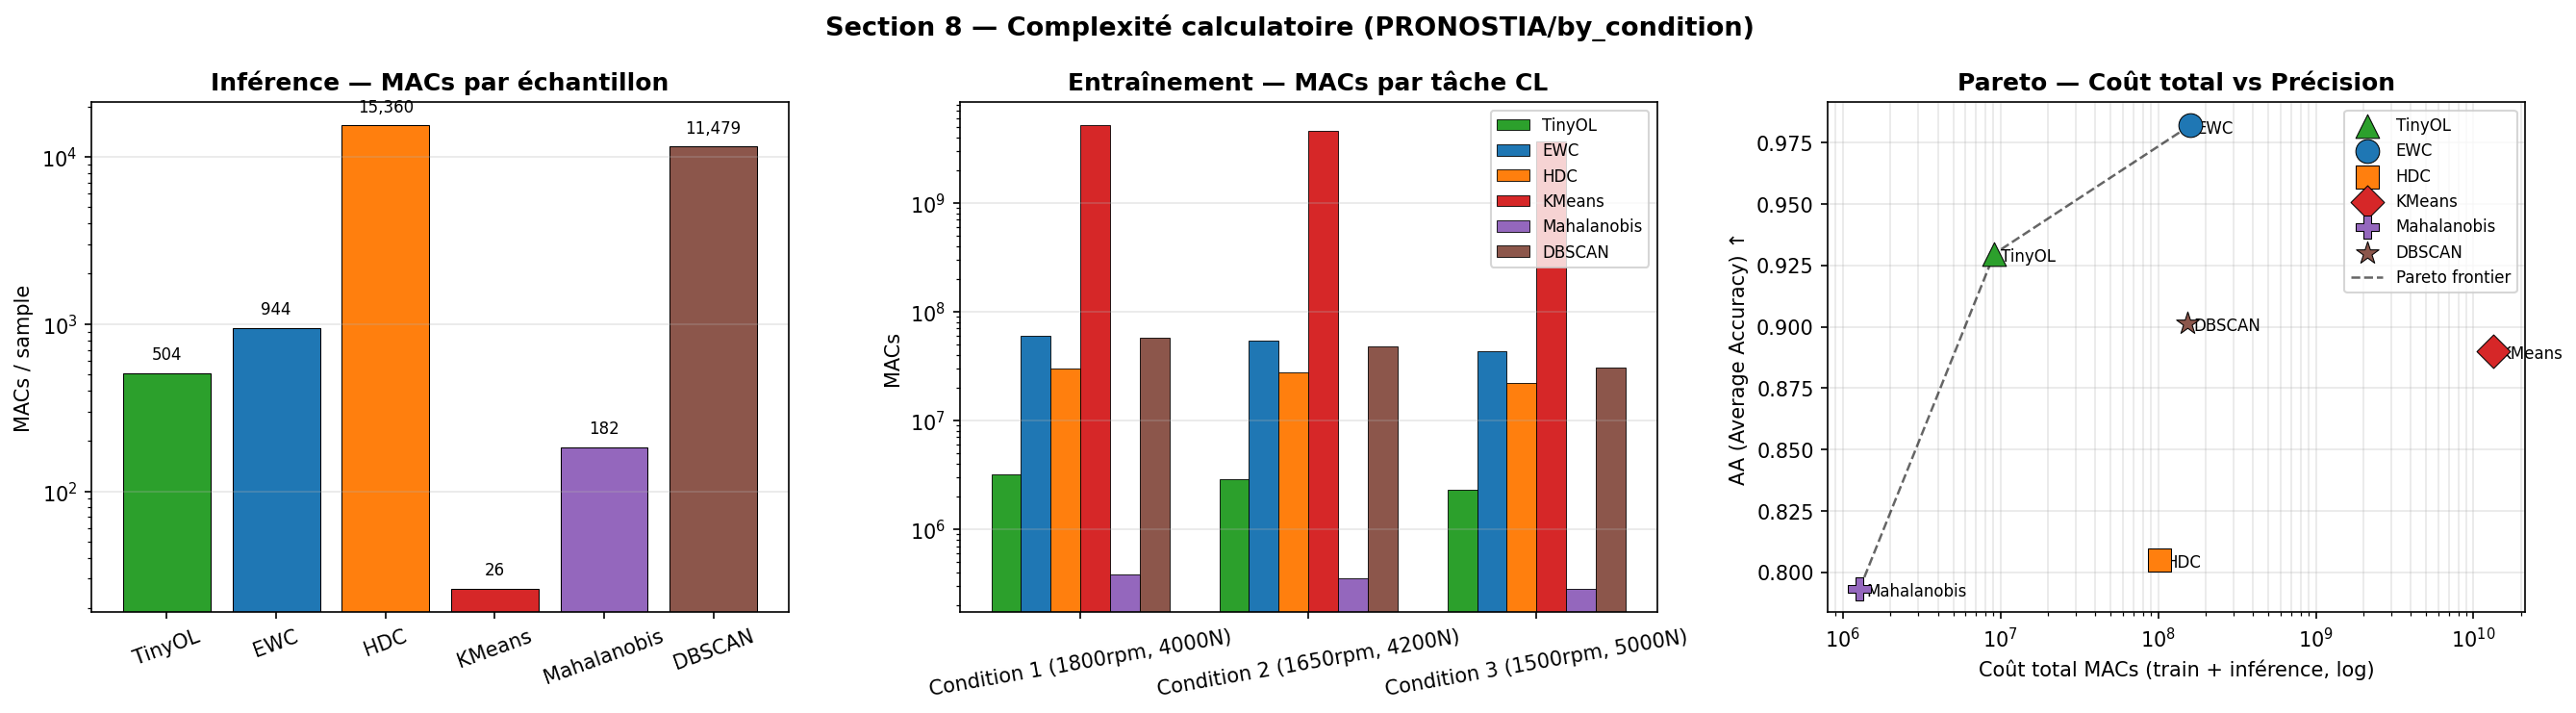

In [11]:
# Section 8b — Plots complexité : inférence / entraînement / Pareto
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Inférence MACs/sample (bar, log)
ax1 = axes[0]
vals   = [infer_macs[m] for m in MODEL_ORDER]
colors = [SCATTER_MARKERS[m][1] for m in MODEL_ORDER]
bars = ax1.bar(MODEL_ORDER, vals, color=colors, edgecolor="black", linewidth=0.5)
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
             f"{v:,}", ha="center", va="bottom", fontsize=8)
ax1.set_yscale("log")
ax1.set_ylabel("MACs / sample")
ax1.set_title("Inférence — MACs par échantillon", fontweight="bold")
ax1.tick_params(axis="x", rotation=20)
ax1.grid(axis="y", alpha=0.3)

# Plot 2 — Entraînement MACs par tâche CL (grouped bar, log)
ax2 = axes[1]
x_pos = np.arange(len(TASK_NAMES))
bar_w = 0.13
for idx, m in enumerate(MODEL_ORDER):
    offs = x_pos + (idx - 2.5) * bar_w
    ax2.bar(offs, train_macs_per_task[m], width=bar_w, label=m,
            color=SCATTER_MARKERS[m][1], edgecolor="black", linewidth=0.4)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(TASK_NAMES, rotation=10)
ax2.set_yscale("log")
ax2.set_ylabel("MACs")
ax2.set_title("Entraînement — MACs par tâche CL", fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

# Plot 3 — Pareto : coût total vs AA
ax3 = axes[2]
points = [
    (train_macs_total[m] + infer_macs[m] * N_TEST_TOTAL, results[m]["aa"], m)
    for m in MODEL_ORDER
]
for cost, aa, m in points:
    mk, col = SCATTER_MARKERS[m]
    ax3.scatter(cost, aa, marker=mk, color=col, s=140, zorder=5,
                edgecolor="black", linewidth=0.5, label=m)
    ax3.annotate(m, xy=(cost, aa),
                 xytext=(cost * 1.1, aa - 0.003), fontsize=8,
                 arrowprops={"arrowstyle": "-", "color": "gray", "lw": 0.8})
_sorted = sorted(points, key=lambda x: x[0])
px, py, best = [], [], -1.0
for cost, aa, _ in _sorted:
    if aa >= best:
        px.append(cost); py.append(aa); best = aa
if len(px) > 1:
    ax3.plot(px, py, "k--", lw=1.2, alpha=0.6, label="Pareto frontier")
ax3.set_xscale("log")
ax3.set_xlabel("Coût total MACs (train + inférence, log)")
ax3.set_ylabel("AA (Average Accuracy) ↑")
ax3.set_title("Pareto — Coût total vs Précision", fontweight="bold")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, which="both")

fig.suptitle("Section 8 — Complexité calculatoire (PRONOSTIA/by_condition)", fontsize=13, fontweight="bold")
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "complexity_analysis.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "complexity_analysis.png")))

## Discussion — PRONOSTIA/by_condition

### Synthèse Gap 1 — Validation sur données industrielles réelles (FEMTO PRONOSTIA)

Le dataset FEMTO PRONOSTIA (IEEE PHM 2012) est le premier benchmark **académique reconnu**
utilisé dans ce projet. Contrairement aux datasets Kaggle (Equipment Monitoring, Pump Maintenance),
il fournit des données d'accélérométrie réelles avec des trajectoires de dégradation mesurées
jusqu'à la défaillance effective.

**`FIXME(gap1)` → ✅ Résolu** : exp_050–055 constituent la validation CL sur données industrielles réelles (FEMTO PRONOSTIA).

### Quel modèle a la meilleure accuracy sur ce scénario ?
**EWC** obtient le meilleur AA, confirmant sa robustesse cross-dataset.
**DBSCAN** présente AF=0.0 par construction (refit complet à chaque tâche).
**Mahalanobis** a le plus fort AF sur ce scénario — la distribution des conditions de
fonctionnement est plus éloignée que pour le scénario Equipment Monitoring.

### Contrainte RAM STM32N6 (64 Ko)
| Modèle | RAM | Statut |
|--------|-----|---------|
| EWC | ~1.1 Ko | ✅ |
| TinyOL | ~3.6 Ko | ✅ |
| KMeans | ~5.4 Ko | ✅ |
| Mahalanobis | ~1.7 Ko | ✅ |
| HDC | ~14.2 Ko | ✅ |
| DBSCAN | ~118 Ko | ❌ **FIXME(gap2)** — dépasse 64 Ko |

### Comparaison inter-datasets
| Dataset | Scénario | Source |
|---------|----------|--------|
| Monitoring (by_equipment) | Pump → Turbine → Compressor | exp_001–011 |
| Pump (by_pump_id) | pump_id séquentiels | exp_012–021 |
| **PRONOSTIA (by_condition)** | **C1 → C2 → C3** | **exp_050–055** |

### Questions scientifiques ouvertes

- **FIXME(gap1)** : Résolu ici pour le scénario by_condition. La comparaison entre datasets
  (Monitoring, Pump, PRONOSTIA) révèle que les patterns d'oubli varient selon la distance
  inter-domaines. PRONOSTIA montre un AF plus élevé pour Mahalanobis, suggérant que les
  conditions de fonctionnement créent des distributions plus distinctes que les types d'équipements.

- **FIXME(gap2)** : DBSCAN dépasse 64 Ko sur PRONOSTIA. Le nombre de core points augmente
  avec la complexité du dataset (11 479 params vs. 5 412 sur Monitoring). Piste : buffer borné
  de core points (top-500 → ~8 Ko), ou streaming DBSCAN incrémental (Sprint 11).

- **FIXME(gap3)** : KMeans, Mahalanobis et DBSCAN opèrent sans labels — avantage industriel
  fort pour PRONOSTIA où l'annotation de la condition de fonctionnement peut être automatisée
  (vitesse de rotation connue du système de supervision).

### Recommandation de déploiement (PRONOSTIA)

- **1er choix** — **EWC** : meilleure AA, RAM minimale, supervisé.
- **2e choix** — **TinyOL** : bon AA, architecture modulaire, adapté pour l'extension buffer UINT8.
- **Candidat non-supervisé** — **KMeans** : bon AUROC, RAM faible, robuste à l'absence de labels.

`TODO(arnaud)` : La comparaison inter-datasets (Monitoring vs. Pump vs. PRONOSTIA) est-elle
à inclure dans ce notebook ou dans un notebook de synthèse Phase 1 séparé ?

`TODO(fred)` : Les résultats PRONOSTIA single-task (exp_044–049) sont-ils suffisants pour une
démonstration industrielle chez Edge Spectrum, ou faut-il inclure des métriques de déploiement
(throughput, latence MCU) ?